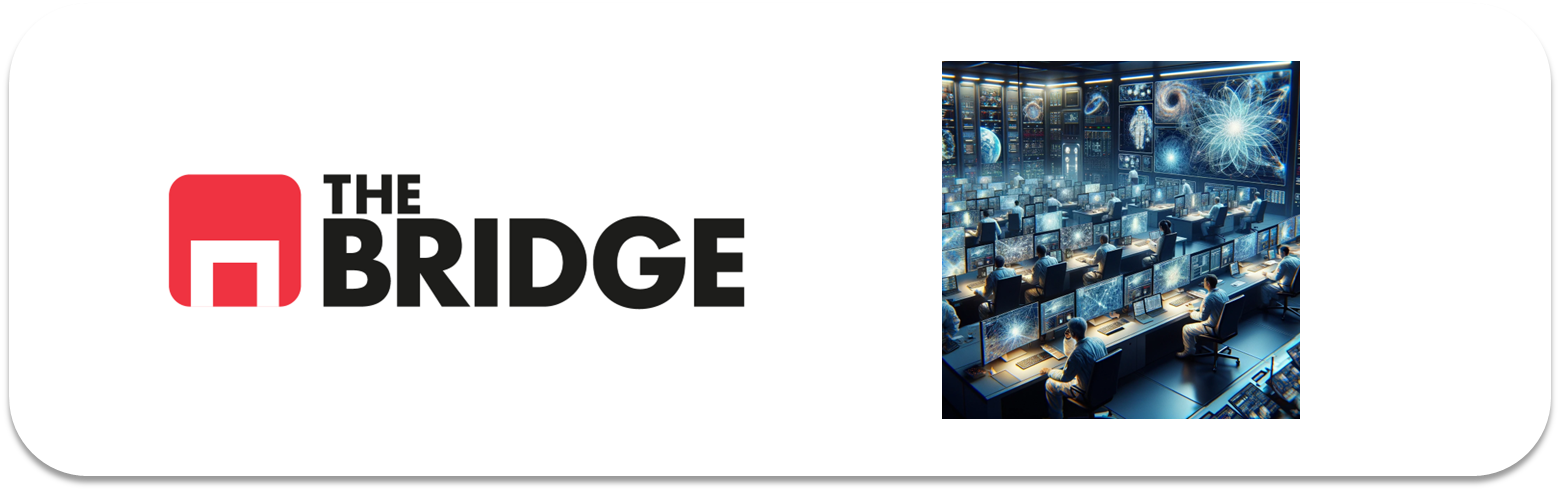

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



In [19]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping

sns.set(style="whitegrid")
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [20]:
IMG_SIZE = 128

train_dirs = [
    "../../Unidad_01_CNN_Redes_Convolucionales/03_Practica_Obligatoria/data/github_train_0",
    "../../Unidad_01_CNN_Redes_Convolucionales/03_Practica_Obligatoria/data/github_train_1",
    "../../Unidad_01_CNN_Redes_Convolucionales/03_Practica_Obligatoria/data/github_train_2",
    "../../Unidad_01_CNN_Redes_Convolucionales/03_Practica_Obligatoria/data/github_train_3"
]

test_dir = "../../Unidad_01_CNN_Redes_Convolucionales/03_Practica_Obligatoria/data/github_test"

In [21]:
for ruta in train_dirs + [test_dir]:
    print(ruta, "->", os.path.exists(ruta))

../../Unidad_01_CNN_Redes_Convolucionales/03_Practica_Obligatoria/data/github_train_0 -> True
../../Unidad_01_CNN_Redes_Convolucionales/03_Practica_Obligatoria/data/github_train_1 -> True
../../Unidad_01_CNN_Redes_Convolucionales/03_Practica_Obligatoria/data/github_train_2 -> True
../../Unidad_01_CNN_Redes_Convolucionales/03_Practica_Obligatoria/data/github_train_3 -> True
../../Unidad_01_CNN_Redes_Convolucionales/03_Practica_Obligatoria/data/github_test -> True


In [27]:
print("Shape X:", X.shape)
print("Shape y_text:", y_text.shape)
print("Primeros filenames:", filenames[:10] if len(filenames) > 0 else "No hay archivos")

Shape X: (0,)
Shape y_text: (0,)
Primeros filenames: No hay archivos


In [28]:
import os

print(os.listdir(train_dirs[0])[:20])

['cat.1000.jpg', 'cat.10010.jpg', 'cat.10012.jpg', 'cat.10013.jpg', 'cat.10017.jpg', 'cat.1002.jpg', 'cat.10023.jpg', 'cat.10024.jpg', 'cat.10027.jpg', 'cat.10030.jpg', 'cat.10037.jpg', 'cat.10045.jpg', 'cat.10048.jpg', 'cat.10055.jpg', 'cat.10058.jpg', 'cat.10059.jpg', 'cat.10067.jpg', 'cat.10070.jpg', 'cat.10072.jpg', 'cat.10077.jpg']


In [29]:
def extract_label_from_filename(filename):
    name = filename.lower()
    
    if name.startswith("cat"):
        return "cat"
    elif name.startswith("dog"):
        return "dog"
    else:
        return None

In [30]:
def load_images_from_folders(folder_list, img_size=128):
    images = []
    labels = []
    filenames = []
    
    for folder in folder_list:
        for file in os.listdir(folder):
            file_path = os.path.join(folder, file)
            
            if not file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
                continue
            
            label = extract_label_from_filename(file)
            if label is None:
                continue
            
            img = cv2.imread(file_path)
            if img is None:
                continue
            
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            
            images.append(img)
            labels.append(label)
            filenames.append(file)
    
    return np.array(images), np.array(labels), filenames

In [31]:
X, y_text, filenames = load_images_from_folders(train_dirs, img_size=IMG_SIZE)
X_test_full, y_test_text, filenames_test = load_images_from_folders([test_dir], img_size=IMG_SIZE)

print("X:", X.shape)
print("y_text:", y_text.shape)
print("X_test_full:", X_test_full.shape)
print("y_test_text:", y_test_text.shape)
print("Primeros labels:", y_text[:10])

X: (4000, 128, 128, 3)
y_text: (4000,)
X_test_full: (1000, 128, 128, 3)
y_test_text: (1000,)
Primeros labels: ['cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat']


In [32]:
class_names = sorted(np.unique(y_text))
class_to_idx = {cls: i for i, cls in enumerate(class_names)}
idx_to_class = {i: cls for cls, i in class_to_idx.items()}

y = np.array([class_to_idx[label] for label in y_text])
y_test_full = np.array([class_to_idx[label] for label in y_test_text])

print("Clases:", class_names)
print(pd.Series(y_text).value_counts())

Clases: [np.str_('cat'), np.str_('dog')]
cat    2000
dog    2000
Name: count, dtype: int64


In [33]:
X = X.astype("float32")
X_test_full = X_test_full.astype("float32")

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_val.shape, X_test_full.shape)

(3200, 128, 128, 3) (800, 128, 128, 3) (1000, 128, 128, 3)


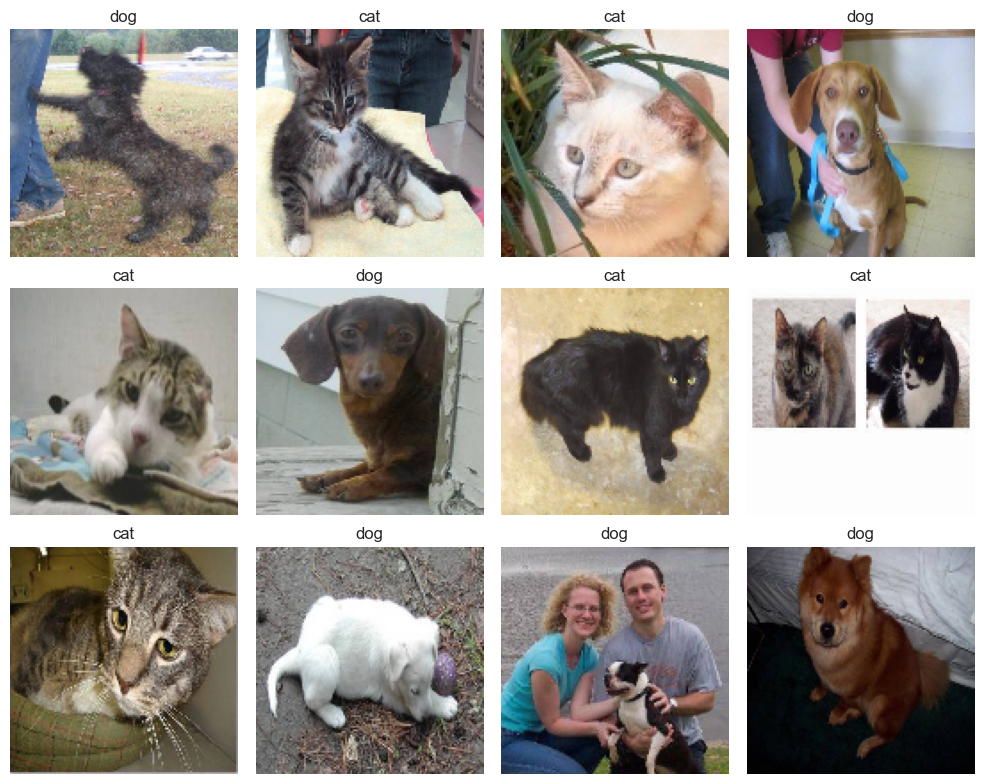

In [34]:
plt.figure(figsize=(10, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i].astype("uint8"))
    plt.title(idx_to_class[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [35]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

model_tl = tf.keras.Model(inputs, outputs)

model_tl.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_tl.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [36]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

history_tl = model_tl.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - accuracy: 0.9547 - loss: 0.1303 - val_accuracy: 0.9737 - val_loss: 0.0810
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.9859 - loss: 0.0452 - val_accuracy: 0.9800 - val_loss: 0.0672
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - accuracy: 0.9909 - loss: 0.0284 - val_accuracy: 0.9775 - val_loss: 0.0746
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.9978 - loss: 0.0119 - val_accuracy: 0.9750 - val_loss: 0.0872
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.9966 - loss: 0.0109 - val_accuracy: 0.9775 - val_loss: 0.0834
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.9981 - loss: 0.0069 - val_accuracy: 0.9762 - val_loss: 0.0972


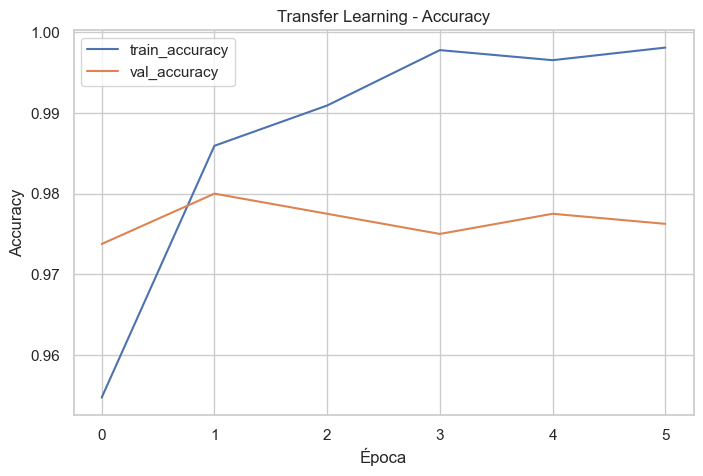

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(history_tl.history["accuracy"], label="train_accuracy")
plt.plot(history_tl.history["val_accuracy"], label="val_accuracy")
plt.title("Transfer Learning - Accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

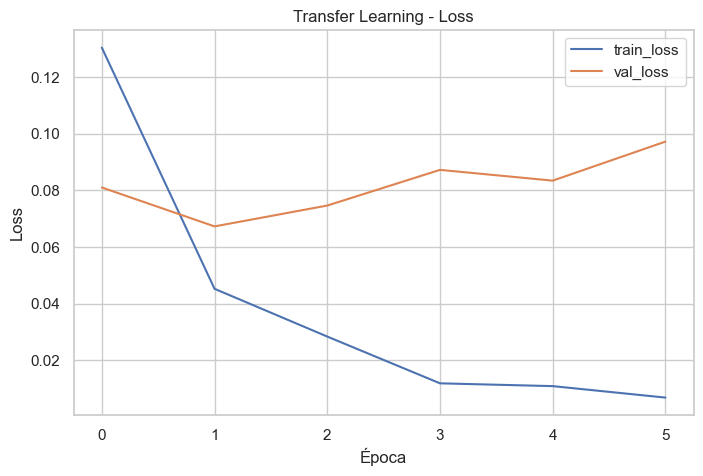

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(history_tl.history["loss"], label="train_loss")
plt.plot(history_tl.history["val_loss"], label="val_loss")
plt.title("Transfer Learning - Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [39]:
test_loss_tl, test_acc_tl = model_tl.evaluate(X_test_full, y_test_full, verbose=0)
print("Test loss:", test_loss_tl)
print("Test accuracy:", test_acc_tl)

Test loss: 0.06751130521297455
Test accuracy: 0.972000002861023


In [40]:
y_proba = model_tl.predict(X_test_full)
y_pred = np.argmax(y_proba, axis=1)

print(classification_report(y_test_full, y_pred, target_names=class_names))

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step
              precision    recall  f1-score   support

         cat       0.97      0.97      0.97       500
         dog       0.97      0.97      0.97       500

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



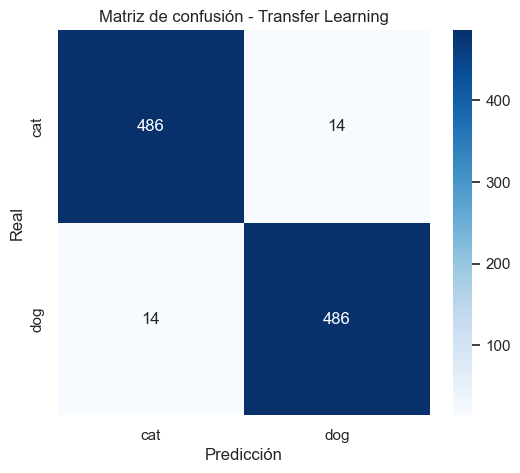

In [41]:
cm = confusion_matrix(y_test_full, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Transfer Learning")
plt.show()

In [42]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [43]:
history_ft = model_tl.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=8,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 151ms/step - accuracy: 0.8972 - loss: 0.2818 - val_accuracy: 0.9812 - val_loss: 0.0658
Epoch 2/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 152ms/step - accuracy: 0.9616 - loss: 0.1117 - val_accuracy: 0.9787 - val_loss: 0.0672
Epoch 3/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - accuracy: 0.9741 - loss: 0.0709 - val_accuracy: 0.9787 - val_loss: 0.0676
Epoch 4/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 131ms/step - accuracy: 0.9712 - loss: 0.0708 - val_accuracy: 0.9800 - val_loss: 0.0675
Epoch 5/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 132ms/step - accuracy: 0.9825 - loss: 0.0461 - val_accuracy: 0.9800 - val_loss: 0.0689


In [44]:
test_loss_ft, test_acc_ft = model_tl.evaluate(X_test_full, y_test_full, verbose=0)
print("Test loss fine tuning:", test_loss_ft)
print("Test accuracy fine tuning:", test_acc_ft)

Test loss fine tuning: 0.07813664525747299
Test accuracy fine tuning: 0.972000002861023


In [45]:
y_proba_ft = model_tl.predict(X_test_full)
y_pred_ft = np.argmax(y_proba_ft, axis=1)

print(classification_report(y_test_full, y_pred_ft, target_names=class_names))

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step
              precision    recall  f1-score   support

         cat       0.97      0.98      0.97       500
         dog       0.98      0.97      0.97       500

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



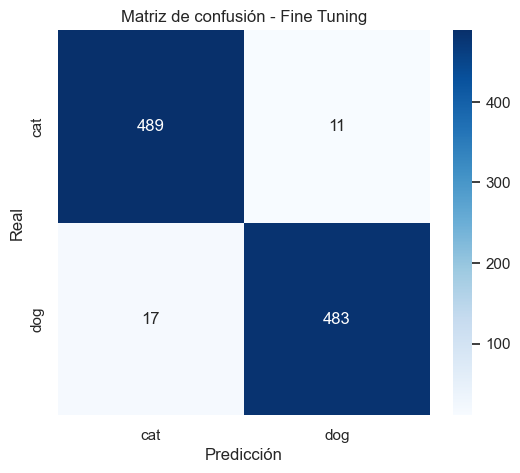

In [46]:
cm_ft = confusion_matrix(y_test_full, y_pred_ft)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_ft,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Fine Tuning")
plt.show()

In [47]:
comparacion = pd.DataFrame({
    "modelo": ["Transfer Learning", "Fine Tuning"],
    "accuracy_test": [test_acc_tl, test_acc_ft],
    "loss_test": [test_loss_tl, test_loss_ft]
})

comparacion

,modelo,accuracy_test,loss_test
0,Transfer Learning,0.972,0.067511
1,Fine Tuning,0.972,0.078137


### Conclusión

Se ha utilizado MobileNetV2 como modelo preentrenado para resolver un problema de clasificación de imágenes de gatos y perros.

Primero se aplicó **transfer learning**, congelando la red base y entrenando únicamente una cabeza densa final. Este enfoque obtuvo un rendimiento muy alto en test.

Después se realizó **fine tuning**, descongelando las últimas capas del modelo base y reentrenando con una tasa de aprendizaje pequeña para adaptar mejor las representaciones al problema.

Finalmente, se compararon ambos enfoques mediante:
- accuracy en test
- classification report
- matriz de confusión

En este caso, el modelo preentrenado ha mostrado un rendimiento muy superior y más eficiente que una CNN construida desde cero, lo que confirma la utilidad del transfer learning en problemas de visión artificial.